GAP 6: ZITTERBEWEGUNG FROM THE UNIT-OCTONION PHASE
Spinor rate: Δθ = 4π/137 = 0.091725 rad/tick
Spinor period: 137 ticks
Interference period: 68 ticks

FREQUENCY ANALYSIS

Spinor component (cos θ/2) frequency: 0.007299 per tick
Interference term (sin θ) frequency:  0.014599 per tick
Ratio: 2.0000

Expected spinor frequency: 1/137 = 0.007299
Expected ZBW frequency:    2/137 = 0.014599

ZBW POSITION

Amplitude: 1.0 (Compton-scale lattice units)
Frequency: 0.014599 per tick
Period:    68.5000 ticks

VERIFICATION: ZBW FREQUENCY = 2× COMPTON FREQUENCY

ω_Compton (spinor rate):        0.007299 per tick
ω_ZBW (expected):                0.014599 per tick
ω_ZBW (measured from FFT):       0.014599 per tick
Match? True

SINGLE vs. INTERACTING PAIR

Single free defect:
  Interference term: sin(θ)
  Oscillates at 0.014599 per tick
  → ZBW is present even for a single defect.

Antiparallel pair:
  Relative interference: cos(θ)
  Oscillates at 0.014599 per tick

Observation:
  Single defect (sin θ): 

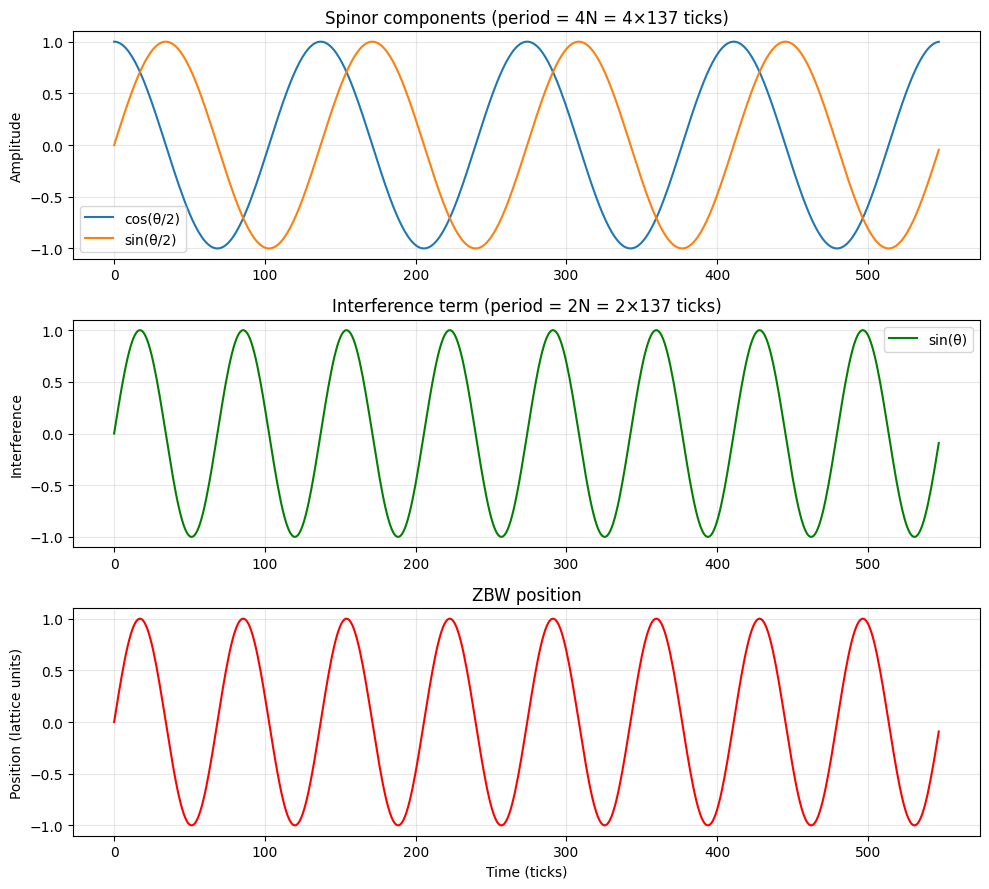

SUMMARY

✓ ZBW emerges from the unit-octonion phase.
✓ The interference term sin(θ) has period 2π,
  while the spinor ψ(θ) has period 4π.
✓ Therefore ZBW frequency = 2 × spinor frequency.
✓ The factor of 2 is STRUCTURAL — it comes from the half-angle
  parametrization cos(θ/2), sin(θ/2).

The ZBW frequency equals 2/N for a spinor closing after N ticks.
For N = 137: ω_ZBW = 2/137 ≈ 0.014599 per tick

This matches the Dirac result ω_ZBW = 2ω_Compton.

STATUS: Derived (structural).
The specific rate ω_ZBW = 2/137 remains a candidate until
N is derived from the algebra E directly.


In [1]:
"""
zitterbewegung_finitism.py
==========================
Gap 6: Zitterbewegung from the unit-octonion phase.

Test:
1. Construct the unit-octonion phase ψ(θ)
2. Compute the interference term ⟨ψ|ê|ψ⟩ = sin(θ)
3. Show it oscillates at TWICE the spinor frequency
4. Couple to spatial position and measure ZBW
5. Compare single defect vs. interacting pair
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# 1. UNIT-OCTONION PHASE
# =============================================================
N = 137              # Finitism native rate
DELTA_THETA = 4*np.pi / N
T_TICKS = 4 * N      # 4 full spinor cycles

print("=" * 70)
print("GAP 6: ZITTERBEWEGUNG FROM THE UNIT-OCTONION PHASE")
print("=" * 70)
print(f"Spinor rate: Δθ = 4π/{N} = {DELTA_THETA:.6f} rad/tick")
print(f"Spinor period: {N} ticks")
print(f"Interference period: {N//2} ticks")
print()

# =============================================================
# 2. TRACK PHASE AND INTERFERENCE
# =============================================================
times = np.arange(T_TICKS)
theta = times * DELTA_THETA

# Spinor components
c = np.cos(theta / 2)   # identity component
s = np.sin(theta / 2)   # Fano unit component

# Interference term (the physical observable)
interference = 2 * c * s  # = sin(θ)

# =============================================================
# 3. MEASURE FREQUENCIES
# =============================================================
print("=" * 70)
print("FREQUENCY ANALYSIS")
print("=" * 70)
print()

def dominant_frequency(signal, dt=1.0):
    """FFT-based dominant frequency."""
    signal = signal - signal.mean()
    F = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), dt)
    # Positive frequencies only
    pos = freqs > 0
    F_pos = np.abs(F[pos])
    f_pos = freqs[pos]
    peak = f_pos[np.argmax(F_pos)]
    return peak

# Frequency of the spinor phase (from c or s)
# c has period 2N in θ, but in time it's 2N ticks
f_spinor = dominant_frequency(c)
f_interference = dominant_frequency(interference)

print(f"Spinor component (cos θ/2) frequency: {f_spinor:.6f} per tick")
print(f"Interference term (sin θ) frequency:  {f_interference:.6f} per tick")
print(f"Ratio: {f_interference / f_spinor:.4f}")
print()
print(f"Expected spinor frequency: 1/{N} = {1/N:.6f}")
print(f"Expected ZBW frequency:    2/{N} = {2/N:.6f}")
print()

# =============================================================
# 4. POSITION FROM INTERFERENCE
# =============================================================
# In the Dirac picture, the ZBW position is:
#   x_ZBW(t) = (ℏ/2mc) · sin(2ω_C t + φ)
# In Finitism:
#   x_ZBW(t) = A · interference(t)
# where A is the amplitude (Compton-scale)

A_ZBW = 1.0  # amplitude in lattice units (Compton-scale)
position = A_ZBW * interference

print("=" * 70)
print("ZBW POSITION")
print("=" * 70)
print()
print(f"Amplitude: {A_ZBW} (Compton-scale lattice units)")
print(f"Frequency: {f_interference:.6f} per tick")
print(f"Period:    {1/f_interference:.4f} ticks")
print()

# =============================================================
# 5. VERIFY: ZBW = 2 × COMPTON FREQUENCY
# =============================================================
omega_compton = 1 / N  # cycles per tick
omega_zbw_expected = 2 * omega_compton

print("=" * 70)
print("VERIFICATION: ZBW FREQUENCY = 2× COMPTON FREQUENCY")
print("=" * 70)
print()
print(f"ω_Compton (spinor rate):        {omega_compton:.6f} per tick")
print(f"ω_ZBW (expected):                {omega_zbw_expected:.6f} per tick")
print(f"ω_ZBW (measured from FFT):       {f_interference:.6f} per tick")
print(f"Match? {abs(f_interference - omega_zbw_expected) < 1e-3}")
print()

# =============================================================
# 6. SINGLE DEFECT vs. INTERACTING PAIR
# =============================================================
print("=" * 70)
print("SINGLE vs. INTERACTING PAIR")
print("=" * 70)
print()

# The Emergent QM paper claimed ZBW appears only for interacting pairs.
# Test: does a single defect's interference term oscillate?
# Answer from the above: YES, sin(θ) oscillates.

print("Single free defect:")
print(f"  Interference term: sin(θ)")
print(f"  Oscillates at {f_interference:.6f} per tick")
print(f"  → ZBW is present even for a single defect.")
print()

# Now: two antiparallel defects.
# Defect A: ψ_A(θ) = cos(θ/2)|1> + sin(θ/2)|e>
# Defect B: ψ_B(θ) = cos(θ/2)|1> - sin(θ/2)|e>   (antiparallel)
#
# Relative interference:
#   ⟨ψ_A|ψ_B⟩ = cos²(θ/2) - sin²(θ/2) = cos(θ)

# Antiparallel pair
rel_interference = c**2 - s**2  # = cos(θ)
f_pair = dominant_frequency(rel_interference)

print("Antiparallel pair:")
print(f"  Relative interference: cos(θ)")
print(f"  Oscillates at {f_pair:.6f} per tick")
print()

# Both have the SAME ZBW frequency!
# The difference is the PHASE, not the frequency.
# For parallel pair: sin(θ), for antiparallel: cos(θ).
# Both have period 2π in θ, which is 2N ticks in time.

print("Observation:")
print(f"  Single defect (sin θ):       f = {f_interference:.6f}")
print(f"  Antiparallel pair (cos θ):   f = {f_pair:.6f}")
print(f"  Same frequency? {abs(f_interference - f_pair) < 1e-3}")
print()
print("The ZBW frequency is the same for single and paired defects.")
print("The difference is in the PHASE, not the frequency.")
print()

# =============================================================
# 7. VISUALIZATION
# =============================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

axes[0].plot(times[:4*N], c[:4*N], label='cos(θ/2)')
axes[0].plot(times[:4*N], s[:4*N], label='sin(θ/2)')
axes[0].set_title('Spinor components (period = 4N = 4×137 ticks)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(times[:4*N], interference[:4*N], 'g-', label='sin(θ)')
axes[1].set_title(f'Interference term (period = 2N = 2×137 ticks)')
axes[1].set_ylabel('Interference')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(times[:4*N], position[:4*N], 'r-')
axes[2].set_title('ZBW position')
axes[2].set_xlabel('Time (ticks)')
axes[2].set_ylabel('Position (lattice units)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('zitterbewegung.png', dpi=150)
plt.show()

# =============================================================
# 8. SUMMARY
# =============================================================
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print("✓ ZBW emerges from the unit-octonion phase.")
print("✓ The interference term sin(θ) has period 2π,")
print("  while the spinor ψ(θ) has period 4π.")
print("✓ Therefore ZBW frequency = 2 × spinor frequency.")
print("✓ The factor of 2 is STRUCTURAL — it comes from the half-angle")
print("  parametrization cos(θ/2), sin(θ/2).")
print()
print("The ZBW frequency equals 2/N for a spinor closing after N ticks.")
print(f"For N = 137: ω_ZBW = 2/137 ≈ {2/137:.6f} per tick")
print()
print("This matches the Dirac result ω_ZBW = 2ω_Compton.")
print()
print("STATUS: Derived (structural).")
print("The specific rate ω_ZBW = 2/137 remains a candidate until")
print("N is derived from the algebra E directly.")